# B24 · Defend the architecture and the thesis

**The win:** write a claim that your evidence can support, choose a fair way to challenge it, and say what result would make you change your mind.

[Previous: B23 · reproduce one comparison](https://avistian.github.io/relational/lessons/b23-declared-comparison.html) · [Context and cost: B18a](https://avistian.github.io/relational/lessons/b18a-context-state.html) · [Metrics: B19a](https://avistian.github.io/relational/lessons/b19a-predictive-distributions.html) · [Next: Year 6 handoff](https://avistian.github.io/relational/plan/year-5-6-bridge.md#b24)

[Student notebook](https://avistian.github.io/relational/labs/b24-architecture-thesis-defense.ipynb) · [Executed notebook](https://avistian.github.io/relational/labs/html/b24-architecture-thesis-defense.html) · [Reference card](https://avistian.github.io/relational/reference/b24-architecture-thesis-defense.html) · [Five-page proposal template](https://avistian.github.io/relational/reference/b24-proposal-template.html) · [Editable template](https://avistian.github.io/relational/labs/b24-proposal-template.md) · [Reproduction contract](https://avistian.github.io/relational/labs/b24-reproduction.md)

**Route through the lesson.** Spend 10 minutes on the claim and worked example, 15 on baselines and falsification, then use the notebook to audit the evidence. Draft the proposal over later sessions. This is the bridge's exit defense; reading it does not mark the bridge complete.



## 1 · Recall the boundary before defending it



Without reopening B23, explain why ten support draws are not ten databases. Recall how B18a counts a rebuilt context and how B19a separates ranking from probability quality. Write one sentence each, then check the linked lessons.

B23 asked whether a declared computation was reproduced. B24 asks which research decision that computation justifies. The mission is to test whether learned relational models deliver value beyond strong single-table systems. A defense must therefore explain where information enters, what the baseline receives, and which observation would contradict the claimed benefit.

A **claim** is a statement about a specified population and procedure. **Evidence** is the observed result and its provenance. A **warrant** is the reasoning connecting the evidence to the claim. A **falsification test** is a planned observation that would make us revise the claim. These four pieces belong together.

> **In plain terms.** “It scored higher” is an observation. “Therefore graph attention is necessary” needs another experiment.



## 2 · Start with the result we actually have

**Frozen experiment.** `B24-RESEARCH-DEFENSE-AUDIT` replays the complete B23 packet: 30 published-model checkpoint evaluations and ten course logistic fits. Each arm uses the same ten draws of 512 labeled supports and the same 702 queries from `rel-f1/driver-dnf`. A **support** is a labeled example available to the predictor. A **query** is a row whose answer is withheld until evaluation.

The primary reading is [RDB-PFN v5, evaluation protocol and Table 9](https://arxiv.org/html/2603.03805v5#A6). Inspect its selected column, then compare the [B23 frozen contract](https://avistian.github.io/relational/labs/b23-reproduction.md). All B23 inputs, target orientation, preprocessing and checkpoints remain fixed. B24 changes only the audit implementation; it makes no new model predictions.



| Arm | Mean AUROC | Sample SD over supports | Evidence lane |
|---|---:|---:|---|
| RDBPFN | 0.721938 | 0.019983 | Selected published configuration |
| RDBPFN_single | 0.663990 | 0.034177 | Selected published configuration |
| TabICLv1.1 | 0.717571 | 0.009769 | Selected published configuration |
| Logistic | 0.643294 | 0.085891 | Course logistic baseline |


**Worked example.** The mean paired RDB-PFN minus TabICL effect is **+0.004366 AUROC**. RDB-PFN wins on six of the ten draws. “Paired” means subtracting model scores with the same support identity before averaging. AUROC measures how often a positive example ranks above a negative one, with half credit for a tie. It does not establish calibrated probabilities. The **sample standard deviation (SD)** describes how scores vary across support draws: subtract their mean, square the differences, sum them, divide by nine for ten draws, then take the square root. It is not a confidence interval for performance on new databases.

<figure class="defense-figure" tabindex="0" role="region" aria-label="All ten paired effects against each comparator; one reused task, not ten databases." style="max-width:100%;overflow-x:auto">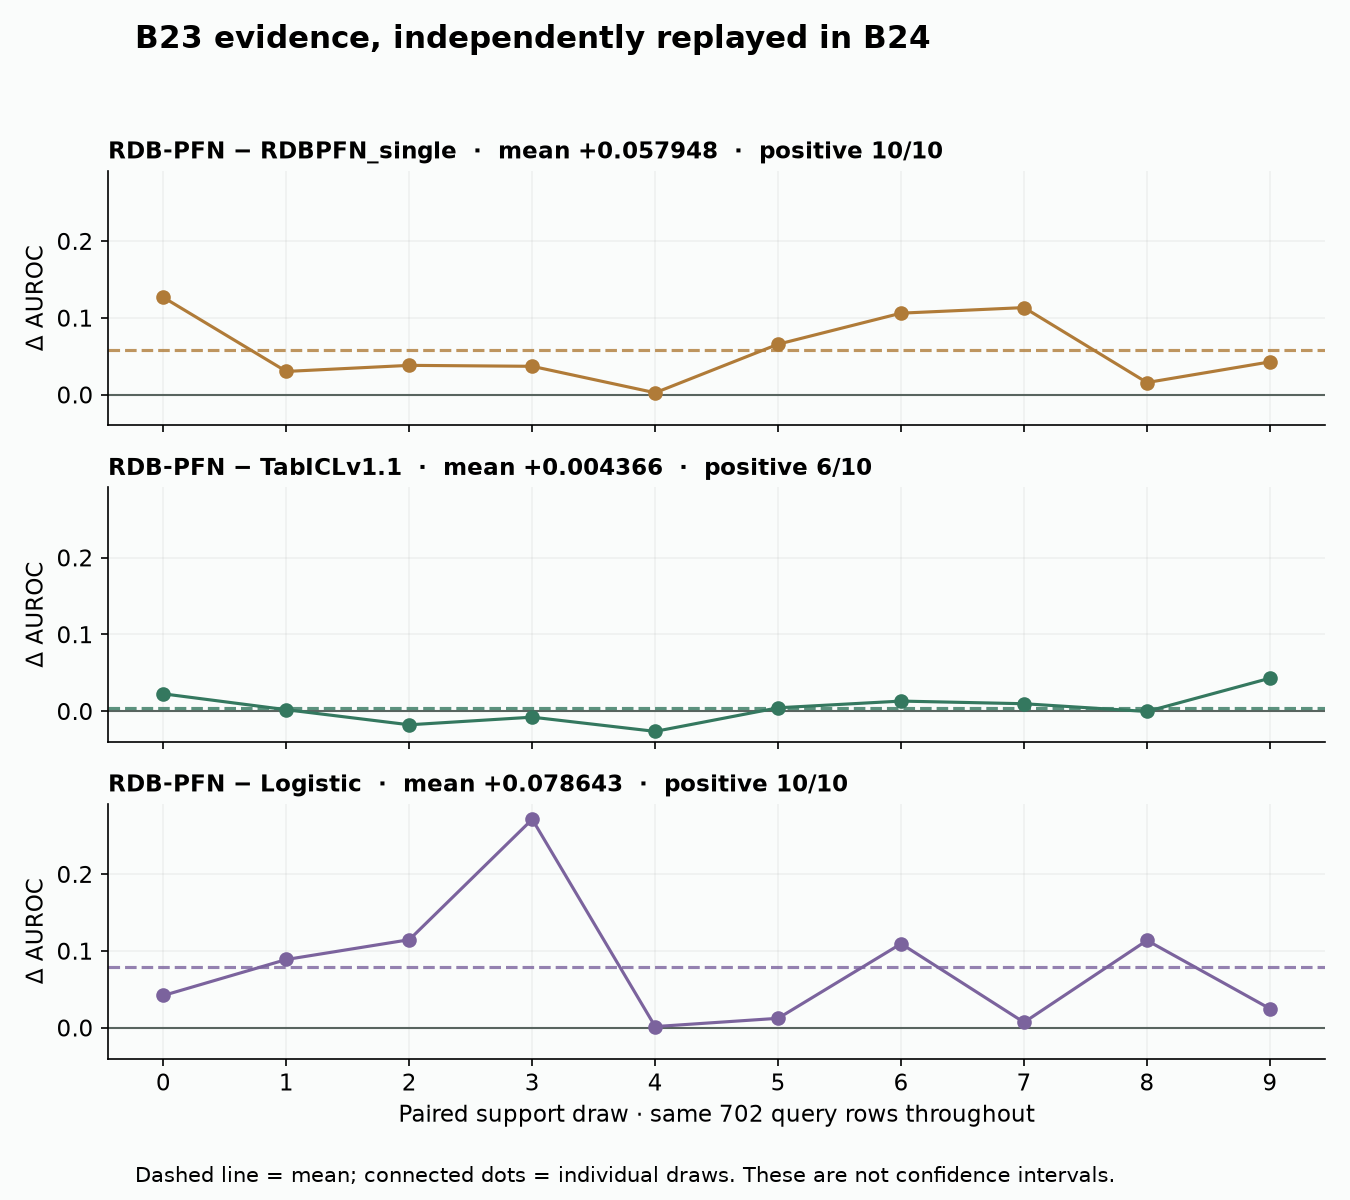<figcaption>All ten paired effects against each comparator; one reused task, not ten databases. On narrow screens, scroll horizontally.</figcaption></figure>

A defensible statement is: “On this released F1 task and these ten support draws, RDB-PFN has a higher mean AUROC than TabICL v1.1.” A stronger statement about other databases needs independent database evidence. A statement about graph-native inference is unsupported by this comparison: RDB-PFN and TabICL here both consume the same materialized feature table.

**Independent replay.** B24 authenticates the archive, checks every complete `(driverId, date)` identity, support identity and label, recomputes all 40 AUROCs using average ranks, and reconstructs all ten logistic probability vectors from saved coefficients. The largest AUROC discrepancy is below `1.2e-16`; the baseline vectors agree exactly. These are replay checks of the B23 artifacts, not another fit.

> **Scope check.** Historical checkpoint identity and raw feature availability remain `NOT_ESTABLISHED`. The checkpoint uses width 96 where the paper appendix describes 128. Released labels retain their original orientation, which complements the current raw DNF reconstruction. Full feature regeneration, pretraining and the whole-paper benchmark remain `NOT_RUN`. Numerical agreement cannot resolve those gaps. B23's fixed logistic comparator is not tuned trees.



## 3 · Defend an information path, not a model name

A **representation** is the form in which information reaches the predictor. An **architecture** is the set of operations mapping that representation to an output. A **training prior** is the distribution of tasks used to learn the weights. Changing any one can change predictions. Name which one your hypothesis concerns.

**Worked example: two histories, one summary.** History A contains values `[0, 1]`; history B contains `[0.5, 0.5]`. Both means equal `0.5`. Their population variances are `0.25` and `0`. A predictor receiving only the mean cannot distinguish them. This is loss in the representation, not proof that the predictor is weak. Add variance to the flat features and the distinction returns.

<figure class="defense-figure" tabindex="0" role="region" aria-label="Illustrative histories: variance repairs a distinction lost by mean-only flattening." style="max-width:100%;overflow-x:auto">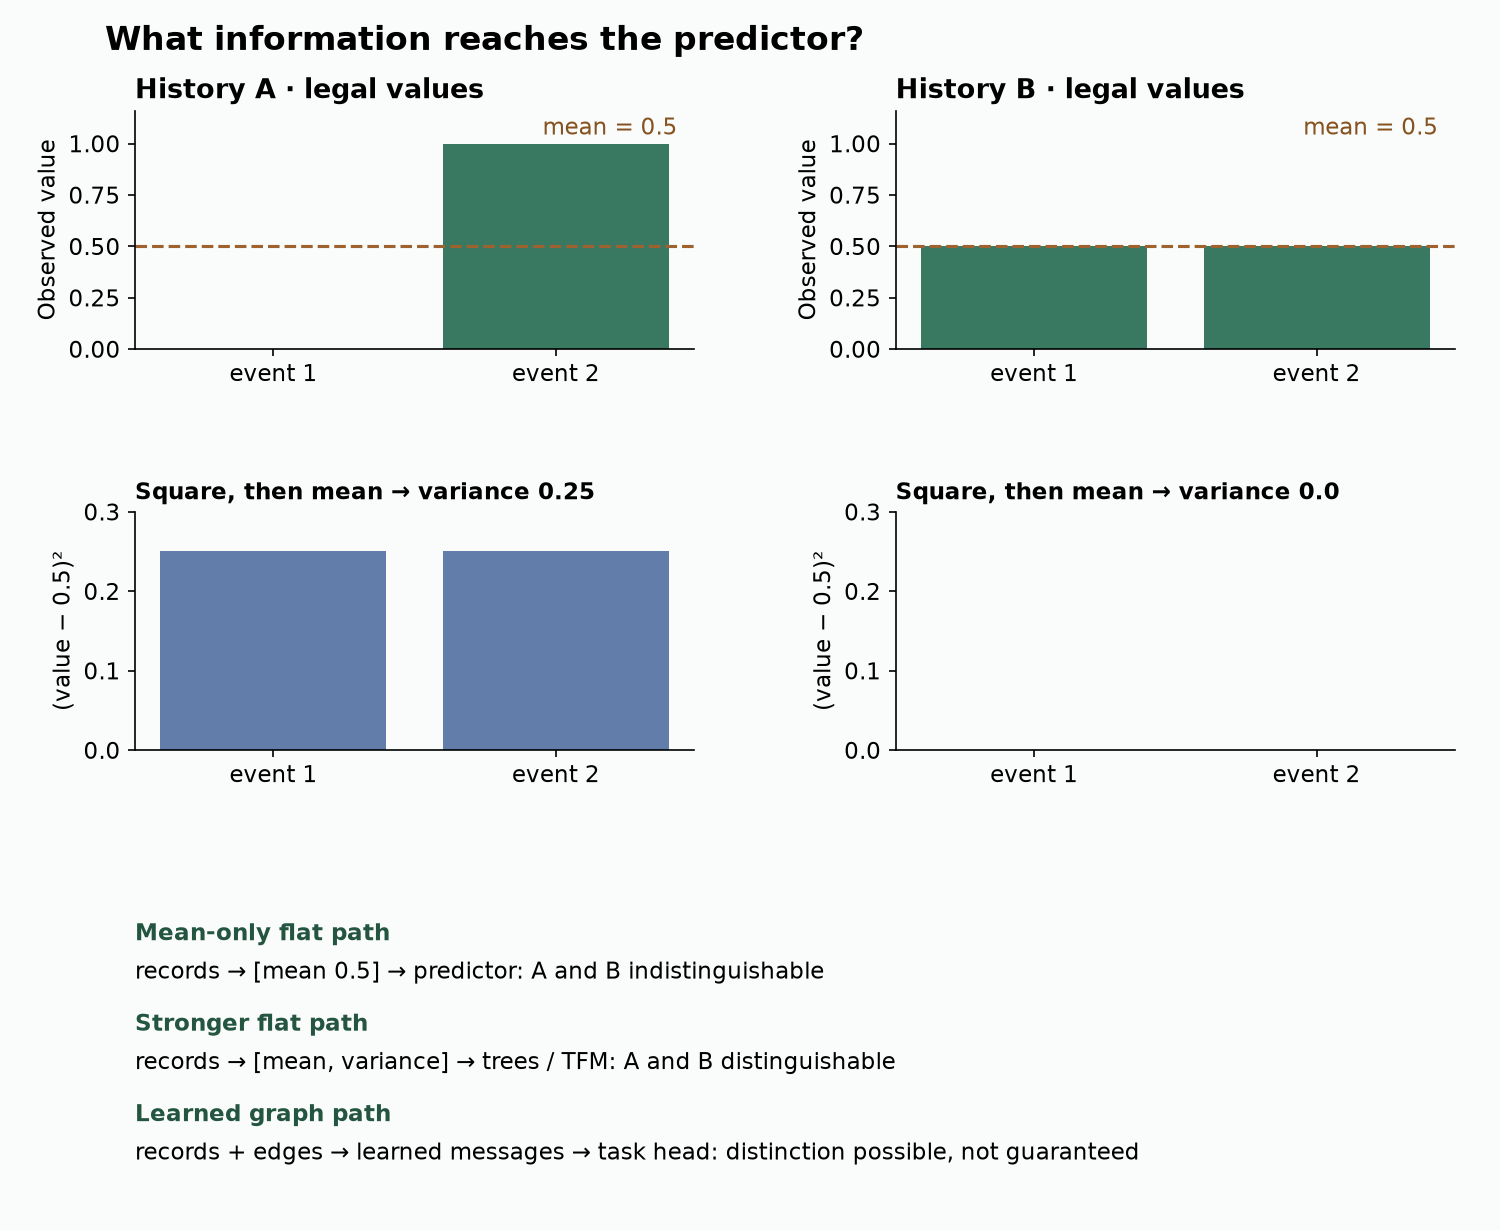<figcaption>Illustrative histories: variance repairs a distinction lost by mean-only flattening. On narrow screens, scroll horizontally.</figcaption></figure>

The diagram asks a precise question: **which operation can preserve the distinction?** For A, subtract the mean to get `[-0.5, 0.5]`, square to get `[0.25, 0.25]`, and average to get `0.25`. For B, both centered values are zero. A learned neighbor aggregator might learn a useful distinction; a hand-built variance feature already supplies this one. Neither is guaranteed to win a real task.

Three architecture paths belong in your proposal:

- **Flat path:** legal historical records → fixed aggregates or deep feature synthesis → vector → trees, a multilayer perceptron (MLP), or a tabular foundation model (TFM) → prediction. An MLP is a stack of learned linear transformations and nonlinear activations. Deep feature synthesis composes declared aggregations along table relationships. It can retain substantial relational information.
- **Graph path:** the same legal records → typed entities and foreign-key edges → learned neighbor messages → entity representation → task head. A task head converts the learned representation into the prediction. See [RelGNN/RelGT mechanisms in B11](https://avistian.github.io/relational/lessons/b11-supervised-relational-baselines.html).
- **Cell path:** legal table cells and their row/column/relationship identities → typed cell tokens → allowed attention operations → task output. Attention combines permitted source vectors according to learned weights. See [RT in B10](https://avistian.github.io/relational/lessons/b10-relational-transformer.html). Trace the actual sampler as well as the attention mask.

RDB-PFN belongs to the flat inference path even though its pretraining generator is relational. TabSTAR's parameter updates differ from forward-only in-context adaptation. A hypernetwork generates predictor weights; a support-context method supplies labeled input state. [B13](https://avistian.github.io/relational/lessons/b13-synthetic-relational-data.html), [B07](https://avistian.github.io/relational/lessons/b07-semantic-transfer.html), and [B07a](https://avistian.github.io/relational/lessons/b07a-hypernetworks.html) supply the model-specific traces.

**Your task.** Sketch your chosen path. Mark one load-bearing operation, its legal inputs, its output, and a simpler operation that could replace it. Predict the effect of that replacement before running it. An **ablation** changes a specified part while preserving the rest of the comparison.



## 4 · Make the baseline capable of disproving you

A **baseline** is a comparator answering a research question. Its value comes from the alternative explanation it tests. A weak baseline may be easy to beat while leaving the central explanation untested.

**Worked decision.** If the thesis says learned graph aggregation improves over engineered summaries, include tuned trees with time-safe features. Give both methods access to the same eligible historical records and target labels. Their representations may differ; record the transformation and cost of building each. Also include a strong flat foundation model to test whether task pretraining, rather than graph computation, explains the gain.

**Matched information** means comparable access to raw observations, labels and prediction-time history. It does not require identical tensors for a graph and a tree. **Matched selection budget** means a declared equal opportunity to choose a configuration using training/validation data. Log total training, feature engineering, inference, failed attempts and human design effort separately. Equal tuning budgets do not equalize inherited pretraining cost.

Use the inventory below to make decisions. “Core” means required in the proposed future comparison unless a task-specific reason is recorded. “Conditional” means include when its mechanism addresses the hypothesis. “Defer” means a named limitation and a reopening condition, never “it would probably lose.” **No inventory row is a new B24 training result.**

| Family / evidence route | Decision for the example proposal | What it tests; reason to reopen |
|---|---|---|
| Tuned trees + time-safe FE · [B14](https://avistian.github.io/relational/lessons/b14-flattening-challenge.html) | **Core** | Can strong engineered summaries explain the gain? Include full feature/search cost and legal history. |
| RealMLP / TabM / TabPack · [B02](https://avistian.github.io/relational/lessons/b02-numerical-embeddings-and-ensembles.html) | **Core family; select and justify** | Could a strong supervised flat neural predictor or ensemble explain it? Pin shared versus packed parameters and budget. |
| TabR / ModernNCA · [retrieval background](https://avistian.github.io/relational/plan/year-5-6-bridge.md#b01) | **Conditional** | Include when local similarity is the proposed advantage; otherwise document neighborhood/metric cost and defer. |
| TabPFN · [B03](https://avistian.github.io/relational/lessons/b03-pfn-tabpfn-generations.html) | **Core candidate** | Strong synthetic-pretrained flat prediction. Choose one version within task/feature/class limits. |
| TabICL · [B04](https://avistian.github.io/relational/lessons/b04-tabicl-scalable-icl.html) | **Core** | Strong flat ICL comparator. B23 uses v1.1; a current v2 run is a separate versioned comparison. |
| TabDPT / Turbo · [B05](https://avistian.github.io/relational/lessons/b05-tabdpt-real-data-retrieval.html) | **Conditional** | Test real-data pretraining plus retrieval; admit overlap and target-free retrieval before execution. |
| Mitra / Mitra-v2 · [B06](https://avistian.github.io/relational/lessons/b06-mitra-prior-mixtures.html) | **Conditional** | Does prior diversity or adaptation explain benefit? Distinguish fine-tuned from forward-only settings. |
| CARTE / ConTextTab / TabSTAR · [B07](https://avistian.github.io/relational/lessons/b07-semantic-transfer.html) | **Conditional on useful text/semantics** | Include name/text controls when semantic information is material. For anonymous numeric inputs, explain omission. |
| SAP-RPT-1-OSS · [official card](https://huggingface.co/SAP/sap-rpt-1-oss) | **Alias of ConTextTab** | Do not double-count the same checkpoint. Commercial SAP variants require separate access records. |
| MotherNet / HyperFast / iLTM · [B07a](https://avistian.github.io/relational/lessons/b07a-hypernetworks.html) | **Conditional on repeated serving** | Does generating a predictor amortize task construction? Count rebuilds and any retained retrieval state. |
| TabFlex / Wide / Orion / TabSwift · [B04a](https://avistian.github.io/relational/lessons/b04a-scaling-rows-features-classes.html) | **Conditional scaling control** | Select one matching the stressed axis: rows, features or classes. A capacity claim alone does not establish accuracy. |
| RDBLearn / TabPFN-Rel · [B14](https://avistian.github.io/relational/lessons/b14-flattening-challenge.html) | **Core relational-information baseline** | How much can stronger flattening/aggregation recover? Pin the information boundary and materialization protocol. |
| RelGNN / RelGT · [B11](https://avistian.github.io/relational/lessons/b11-supervised-relational-baselines.html) | **Core graph family** | Test learned relational computation directly. Select one justified architecture and preserve task-specific tuning. |
| RT-v1 / accessible relational FM · [B10](https://avistian.github.io/relational/lessons/b10-relational-transformer.html), [B12](https://avistian.github.io/relational/lessons/b12-adaptation-mechanisms.html) | **Conditional on hypothesis/access** | Test cell-level or cross-task transfer when authenticated checkpoints and legal inputs are available. Missing access is not a negative result. |
| Griffin / OpenRFM / KumoRFM · [B12](https://avistian.github.io/relational/lessons/b12-adaptation-mechanisms.html) | **Conditional, each access mode separate** | State whether weights, context or both adapt. Public and provider-controlled systems need distinct reproducibility records. |
| RDB-PFN / PluRel · [B13](https://avistian.github.io/relational/lessons/b13-synthetic-relational-data.html) | **RDB-PFN evidence; PluRel conditional** | Relational synthetic pretraining is distinct from graph-native prediction. B23 supports a released flat-input result only. |
| LimiX · [official release](https://github.com/limix-ldm-ai/LimiX) | **Defer joint-objective extension** | Ranking-only example does not test joint imputation. Reopen when missing-value modeling is the hypothesis; freeze exact release/terms. |
| TabFM · [primary report](https://arxiv.org/html/2609.37959v1) | **Conditional flat comparator** | Base, TabFM+ and TabFM-Auto differ in ensembling/feature/search work. Reopen after the chosen operating point fits the declared budget. |
| EXAONE · [primary report](https://arxiv.org/html/2608.25774v1) | **Conditional flat comparator** | Cross-axis processing is another explanation for strong flat predictions. Select on development evidence and budget, not final test rank. |
| Nori · [official card](https://huggingface.co/Synthefy/Nori/blob/main/README.md) | **Conditional flat comparator** | Include if the pinned released task/configuration fits the comparison; model-card access is not full pretraining evidence. |
| RT-J · [author page](https://star-project.stanford.edu/rt-j/) | **Defer until artifact admission** | A separate candidate from RT-v1; require original checkpoint/code/protocol identity before a named reproduction. |
| Seldon · [provider report](https://www.neuralk.ai/white-paper/seldon-foundation-made-tabular) | **Excluded from B24 execution** | Zero-paid-compute replay does not evaluate provider access. Reopen with a matched protocol and approved cost; provider benchmark is not independent replication. |
| NEXUS · [official product page](https://fundamental.tech/nexus) | **Excluded from B24 execution** | Product/API claims are insufficient for a numerical comparison. Reopen with reproducible inputs, outputs, version and approved access budget. |


**Current candidate check · 4 October 2026.** The [source receipt](https://avistian.github.io/relational/labs/sources/b24/candidate-audit.json) records the dated official pages and access results. This is a candidate/source audit, not a current leaderboard. LimiX-2, TabFM, EXAONE, Nori and RT-J remain explicit decisions even if their elective was skipped. Seldon and NEXUS provider claims require the same information/cost protocol before comparison. A provider-controlled benchmark is not independent verification.

**Selection rule.** Pick a compact set that can falsify the chosen explanation. If the full comparison exceeds the budget, report the missing runs and narrow the empirical claim. Do not remove a strong competitor after seeing its test score. Cite both the reason for exclusion and the evidence that would reopen the decision.



## 5 · Freeze two ways the thesis could fail

A falsification rule must name the task, challenger, reference, primary metric, direction, numerical threshold, matched information and selection budget, and the action taken if the rule fires. **Preregistration** means fixing those decisions before inspecting the evaluation outcomes they govern.

For a higher-is-better metric such as AUROC, define the oriented effect as challenger minus reference. For a lower-is-better loss, define it as reference minus challenger. Positive then always favors the challenger. A rule such as “revise if mean effect is at most zero” has an unambiguous boundary: a tie triggers revision.

1. **Simpler-baseline test.** On a named future task, compare the proposed relational method with tuned trees plus time-safe features. If the prespecified paired mean effect is at most zero, withdraw superiority on that task. Preserve every planned run, including failures. A practical margin greater than zero can be chosen before evaluation if the deployment benefit requires it.
2. **Untouched-task test.** Lock a database/task that has not informed checkpoint, architecture, feature, prior or threshold selection. Compare with the locked strongest baseline. If the effect is at most the prespecified threshold, narrow the transfer claim. Record prior dataset use across this course; another F1 support seed is not an untouched task.

An untouched task is stronger evidence than another seed, but one new task still cannot establish universal transfer. If no genuinely untouched candidate is available, record `PENDING_TASK_RESERVATION`; do not relabel a reused benchmark. Uncertainty should match the sampling unit: show support variability within tasks and task-level variability when claiming cross-task benefit.

**Manual reversal exercise:** threshold0, effects−.005,0,+.005. Which trigger revision? What changes when information access is unmatched?

**Metric contract from B19a.** State whether the decision needs ranking, class probabilities, a point estimate or a predictive distribution. The example F1 claim is ranking-only, so AUROC is primary and calibration is unestablished. **Calibration** asks whether stated probabilities agree with observed frequencies. A **proper probability score** rewards reporting the true probability distribution in expectation. If a downstream decision uses probabilities, predeclare such a score, a separate calibration partition and calibration diagnostics. Do not fit calibration on final test labels. [Use the metric/calibration contract](https://avistian.github.io/relational/labs/b19a-metric-contract.md).

**Context contract from B18a.** Freeze support selection, support-label availability, preprocessing, checkpoint, cache identity, update trigger, rebuild frequency, cold/warm latency, memory and total cost. Define what happens when an entity or label arrives late. Changing a support row can change the deployed predictor without changing weights. [Review context as state](https://avistian.github.io/relational/lessons/b18a-context-state.html).

**Task expansion is conditional.** If your thesis forecasts future outcomes, add B19b's horizon, origin and as-of covariate contract. For a static classification thesis, explicitly mark forecasting out of scope. [Forecasting contract](https://avistian.github.io/relational/labs/b19b-task-contract.md).



## 6 · A score cannot repair invalid evidence

The defense rubric has five axes. Score each 0 for missing/invalid, 1 for partial, or 2 for complete and justified. An assessor must read the actual proposal and evidence; string-filled fields are not proof.

| Axis | What earns 2 |
|---|---|
| Protocol validity | Frozen identities, temporal availability, selection and metric; unresolved gaps bar claims needing them. |
| Baseline fairness | Strong relevant comparators, matched information and selection budgets, justified exclusions. |
| Reproducibility | Named scope, executable path, immutable inputs/predictions and complete evidence for the declared claim. |
| Evidence interpretation | Effect and variability at the right unit; source, replay, fresh execution and historical claims separated. |
| Falsifiability | Two concrete reversal tests with untouched-task audit and a decision that changes if they fail. |

Eligibility requires **at least 8/10, no zero, no unresolved leakage, and the required reproduction evidence**. A proposal about future research may cite complete selected-release evidence while declaring historical validity open. A claim of historically valid deployment cannot pass using the same packet. The assessor determines which gate the actual claim requires.

<figure class="defense-figure" tabindex="0" role="region" aria-label="Illustrative eligibility cases; missing validity cannot be repaired with rubric points." style="max-width:100%;overflow-x:auto">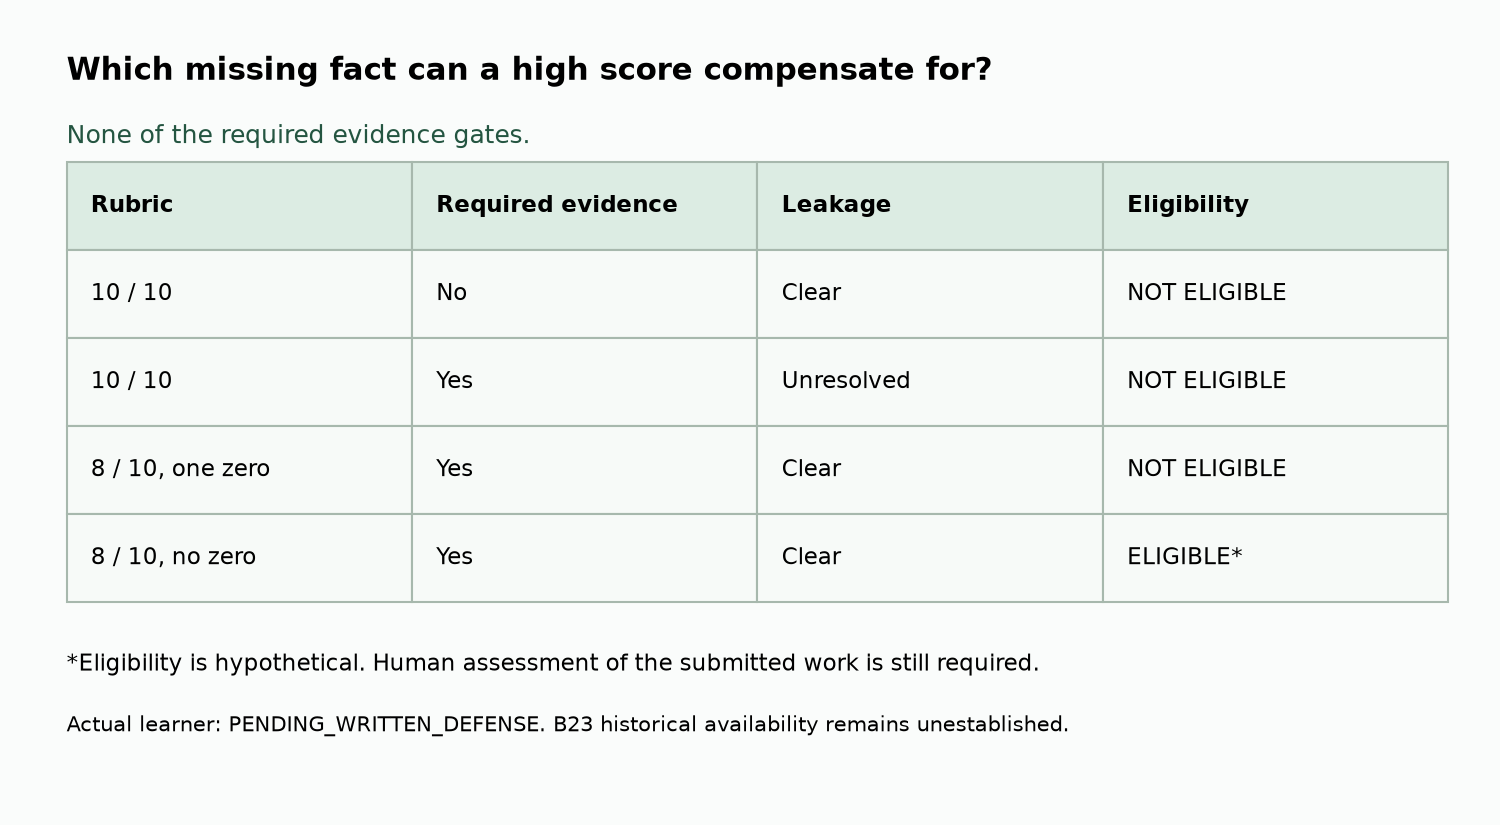<figcaption>Illustrative eligibility cases; missing validity cannot be repaired with rubric points. On narrow screens, scroll horizontally.</figcaption></figure>

**Manual gate exercise:** try10/10with missing reproduction, then8/10with one zero. Explain why neither is eligible; keep learner assessment separate.

> **Scope check.** The controls simulate hypothetical assessment inputs. They do not change the actual B23 evidence or grade your writing. Your status remains `PENDING_WRITTEN_DEFENSE` until your submission is assessed. A replay proves executable evidence, not learner mastery.



## 7 · Build the five-page defense

Open the [printable proposal template](https://avistian.github.io/relational/reference/b24-proposal-template.html). It supplies five page-sized prompts, not a filled learner answer:

1. **Hypothesis and claim:** population, mechanism, practical motivation, current evidence and nonclaims.
2. **Architecture and coverage:** your end-to-end information path and justified family inventory.
3. **Frozen protocol:** identities, splits, availability, selection, metrics, context/update/cost contracts.
4. **Evidence and limits:** B23 replay, per-draw effects, deviations, run status and missing historical facts.
5. **Falsification and decision:** two reserved tests, rubric evidence and next research action.

**A short worked opening, not your submission.** “I hypothesize that learned neighbor aggregation can improve a specified future task beyond tuned trees with time-safe aggregates at a fixed selection budget. B23 motivates studying pretrained predictors: it shows a small positive mean RDB-PFN–TabICL difference on one released F1 task. Both methods use flattened inputs, so this does not establish my graph hypothesis. I will test the graph-specific claim with matched eligible records and a strong flat comparator. Missing historical feature provenance bars a deployment-validity claim from B23.”

The notebook implements three decisions you need to defend: pair effects by draw identity, apply the rubric without bypassing gates, and reject incomplete falsification contracts. Blank and incorrect functions must fail before a report is produced. **A validator checks structure; it cannot verify that your prose is true or that a task was never used.** Attach the underlying prior-use and availability evidence for the assessor.





## 8 · Exit and Year 6 handoff

Submit the proposal, architecture map, baseline table, B23 evidence folder plus B24 replay receipt, and two falsification contracts. Ask the agent to challenge one warrant and assess each rubric axis. Do not fill a learning record from author-run checks.

| Next lesson | B24 handoff |
|---|---|
| L201 · Hypothesis | Narrow claim, mechanism and revision condition. |
| L202 · Sources | Versioned primary-source matrix and access/deviation ledger. |
| L203 · Protocol | Task reservation, splits, legal information, selection and metrics. |
| L204 · Baselines | Inclusion/exclusion decisions and total budget accounting. |
| L219 · Stress tests | Simpler-baseline and untouched-task failure rules. |

**Return after 1, 7 and 30 days.** Day 1: derive the two-history variance example from memory. Day 7: defend one exclusion, then argue for including it. Day 30: reconstruct the two failure rules without looking. Bring any unclear step back to the agent; ask for another worked example or a skeptical review.



## Reproduction appendix · exact scope and commands

From the repository root, run:

```bash
.venv/bin/python labs/_budget_b24.py .venv/bin/python labs/_audit_b24.py
.venv/bin/python labs/_budget_b24.py .venv/bin/python labs/_verify_b24.py
```

The downloaded notebook embeds the authenticated evidence and visible audit code; it needs only Python and NumPy to replay. It can run without a repository checkout or network access. The executed HTML is an author reference. Live Colab execution remains `NOT_CHECKED`.

B24 uses a **$0 paid-compute budget** and a **3,600-second aggregate local numerical/check cutoff**, including preparation, failures and validation. The [local ledger](https://avistian.github.io/relational/labs/evidence/b24/local-budget.json) records attempts. At cutoff, leave `INCOMPLETE`; retain all declared runs in the contract. A separate fresh-inference path remains documented in [B23](https://avistian.github.io/relational/labs/b23-reproduction.md); B24 does not dispatch it.

[Full replay report](https://avistian.github.io/relational/labs/evidence/b24/report.json) · [Independent verification](https://avistian.github.io/relational/labs/_verify_b24_results.json) · [Primary paper](https://arxiv.org/html/2603.03805v5) · [Bridge specification](https://avistian.github.io/relational/plan/year-5-6-bridge.md#b24)


## PROVIDED · offline evidence and environment
Tier B: real released relational task evidence; no new inference. Only Python and NumPy are needed. Install NumPy if absent. The base64 packet below is hidden in prepared HTML; all audit operations and learner functions are visible. The three TODOs must drive your report. This notebook is a standalone replay, not a model training lab.

In [1]:
import base64, hashlib, io, json, math, sys, tempfile, zipfile
from pathlib import Path
import numpy as np
# @colab-bootstrap: embedded authenticated evidence; no checkout or network required.

In [2]:
packet=base64.b64decode('...')
assert hashlib.sha256(packet).hexdigest()=='77caef57cff7e0a6b8ba96f64c8e6c62e6b083083e824d4e83800faa714922c1'
manifest={'b23-packet.zip': '5c18c089dd76c2a461891c553a5b22b4a362a5397d89910f506279fce83cbecf', 'source-identity.json': '5ba57e9f5314058a0c8fb2da1b32608d93dd3f45e701cbbe0d4678a4bc9109dc', 'report.json': 'a6cb5c30e1be7c6672d2a25c304ce2af36ebde761ab307d0084b30c4c8e528c1', '_audit_b24.py': 'df642f64d2ab6f00ffc52fa4d697a3044dcba6d9507953349da9e2374098eeae', '_test_b24.py': 'd2ef7fed7daa7b797d89bbc49416bc6f52d6f863e049ca98fe28738f876b820f', 'relkit/defense_b24.py': '489a86cf3bb81df0bebfa36a8e30de101e8ed275a2902aed3952712cebac122e', 'relkit/__init__.py': 'e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855', 'b24-reproduction.md': '2a40376b80da82513e326378842d56d9691047b18cdd720588ea7cdd9a349704', 'b24-proposal-template.md': '01516b214d1ea2e9351ea4b3796ee567fb36e2bcda452c3ae48e1dd63799671e', 'sources/coverage.md': '2ad7dcde6f74eff129c031a6157bca40b1fbc3e75e0e034e2a844045e9ad0fa0', 'sources/candidate-audit.json': '4d6b7987e4fc9ff4911f41a53892b9cca036609c5a73ff9b74eb497d6ea97712'}
root=Path("b24-portable");root.mkdir(exist_ok=True)
with zipfile.ZipFile(io.BytesIO(packet)) as archive:
    for name,digest in manifest.items():
        content=archive.read(name);assert hashlib.sha256(content).hexdigest()==digest
        target=root/name;target.parent.mkdir(parents=True,exist_ok=True);target.write_bytes(content)
sys.path.insert(0,str(root.resolve()))
identity=json.loads((root/"source-identity.json").read_text())
ARMS=["RDBPFN","RDBPFN_single","TabICLv1.1","Logistic"]

## PROVIDED · authenticate and independently score
`unpack` requires the frozen digest before reading evidence. `rank_auc` uses average ranks: subtract the positive-rank sum under perfect bottom ranking, then divide by positive×negative pairs. Inspect the tie loop. `scan` checks every declared run and reconstructs the fixed baseline from its saved fit state.

In [3]:
def unpack(packet, identity, target):
    raw=Path(packet).read_bytes()
    if hashlib.sha256(raw).hexdigest()!=identity['packet_sha256']:raise ValueError('Frozen B23 archive changed')
    target=Path(target).resolve()
    with zipfile.ZipFile(io.BytesIO(raw)) as z:
        for name in z.namelist():
            dest=(target/name).resolve()
            if not dest.is_relative_to(target):raise ValueError('Unsafe archive path')
            dest.parent.mkdir(parents=True,exist_ok=True);dest.write_bytes(z.read(name))
    root=target/'evidence/b23';m=json.loads((root/'packet-manifest.json').read_text())
    for name,digest in m['files'].items():
        if hashlib.sha256((root/name).read_bytes()).hexdigest()!=digest:raise ValueError('Changed evidence '+name)
    return root

In [4]:
def rank_auc(labels, probabilities):
    """Average ranks for ties, implemented independently of B23's pair-count metric."""
    y=np.asarray(labels);p=np.asarray(probabilities)
    if y.ndim!=1 or p.shape!=y.shape or not np.isin(y,[0,1]).all() or not np.isfinite(p).all() or ((p<0)|(p>1)).any():raise ValueError('Invalid labels/probabilities')
    pos=int(y.sum());neg=len(y)-pos
    if not pos or not neg:raise ValueError('AUROC needs both classes')
    order=np.argsort(p,kind='stable');ranks=np.empty(len(p));i=0
    while i<len(p):
        j=i+1
        while j<len(p) and p[order[j]]==p[order[i]]:j+=1
        ranks[order[i:j]]=(i+1+j)/2;i=j
    return float((ranks[y==1].sum()-pos*(pos+1)/2)/(pos*neg))

In [5]:
def scan(root):
    """Check semantics even if a corrupted receipt has been rehashed by a writer."""
    root=Path(root);records=[];errors=[];baseline_errors=[]
    with np.load(root/'packet/prepared.npz',allow_pickle=False) as d:
        keys=d['test_keys'];labels=d['y_test'];supports=d['support']
        if keys.shape!=(702,2) or len(set(map(tuple,keys)))!=702 or supports.shape!=(10,512):raise ValueError('Wrong complete query/support grid')
        seen=set()
        for phase in ['pilot-1','full-1','baseline-1']:
            receipt=json.loads((root/phase/'receipt.json').read_text())
            for row in receipt['records']:
                arm=row['arm'];s=row['seed']
                if arm not in ARMS or type(s) is not int or s not in range(10) or (arm,s) in seen:raise ValueError('Wrong or duplicate run')
                if row['rows']!=702 or row['support']!=512:raise ValueError('Wrong row count')
                seen.add((arm,s));path=root/phase/f'{arm}-{s}.npz'
                if hashlib.sha256(path.read_bytes()).hexdigest()!=row['sha256']:raise ValueError('Prediction digest mismatch')
                with np.load(path,allow_pickle=False) as x:
                    if not np.array_equal(x['keys'],keys) or not np.array_equal(x['label'],labels) or not np.array_equal(x['support_keys'],d['train_keys'][supports[s]]):raise ValueError('Wrong keys, labels or support identities')
                    if len(set(map(tuple,x['support_keys'])))!=512 or set(map(tuple,keys))&set(map(tuple,x['support_keys'])):raise ValueError('Support leakage/duplicates')
                    value=rank_auc(labels,x['probability']);err=abs(value-row['auc'])
                    if not np.isfinite(row['auc']) or err>1e-12:raise ValueError('Metric receipt mismatch')
                    errors.append(err);records.append(dict(arm=arm,seed=s,auc=value))
                    if arm=='Logistic':
                        X=d['X_train'][supports[s]].copy();Q=d['X_test'].copy()
                        med=np.array([np.median(c[~np.isnan(c)]) if (~np.isnan(c)).any() else 0. for c in X.T])
                        X=np.where(np.isnan(X),med,X).astype(X.dtype).astype(float);Q=np.where(np.isnan(Q),med,Q).astype(Q.dtype)
                        mean=X.mean(0);scale=X.std(0);scale[scale==0]=1
                        if not np.allclose(med,x['median'],rtol=0,atol=1e-12) or not np.allclose(mean,x['mean'],rtol=0,atol=1e-12) or not np.allclose(scale,x['scale'],rtol=1e-10,atol=1e-10):raise ValueError('Baseline fit-state mismatch')
                        # B23 sklearn1.9 float32 transform casts statistics to the input dtype.
                        Q-=mean.astype(Q.dtype);Q/=scale.astype(Q.dtype)
                        prob=1/(1+np.exp(-(Q@x['coef'][0]+x['intercept'][0])))
                        error=float(np.max(np.abs(prob-x['probability'])));baseline_errors.append(error)
                        if error>1e-10:raise ValueError('Baseline probability mismatch')
        if seen!={(a,s) for a in ARMS for s in range(10)}:raise ValueError('Incomplete declared 40-run experiment')
    return records,dict(independent_auc_runs=len(errors),baseline_vectors_reconstructed=len(baseline_errors),max_auc_error=max(errors),max_baseline_error=max(baseline_errors))

In [6]:
assert rank_auc([1,0,1,0],[.8,.5,.5,.2])==.875
with tempfile.TemporaryDirectory() as td:
    evidence=unpack(root/"b23-packet.zip",identity,td)
    records,verification=scan(evidence)
assert len(records)==40
print(verification)

{'independent_auc_runs': 40, 'baseline_vectors_reconstructed': 10, 'max_auc_error': 1.1102230246251565e-16, 'max_baseline_error': 0.0}


## TODO · Pair before interpreting
**Goal and contract:** Return reference,challenger,seeds,per_seed,mean,sample_sd and positive. Reject missing/duplicate/nonfinite matched data. Pair by draw identity, never row order. Use sample SD; positive means higher challenger AUROC.

**Why:** this decision affects whether your evidence supports the proposal. Implement the function before running CHECK. The examples are teaching fixtures, not a submitted research plan.

In [7]:
def paired_effect(records, reference, challenger):
    """Pair all declared draws by identity; positive means higher challenger AUROC."""
    if not isinstance(reference,str) or not isinstance(challenger,str) or reference==challenger:
        raise ValueError('Choose two distinct arms')
    by_arm={reference:{},challenger:{}}
    for row in records:
        if not isinstance(row,dict) or not {'arm','seed','auc'}<=row.keys():raise ValueError('Missing record fields')
        if row['arm'] not in by_arm:continue
        seed=row['seed'];value=row['auc']
        if type(seed) is not int or seed<0 or seed in by_arm[row['arm']]:raise ValueError('Invalid or duplicate draw')
        if not isinstance(value,(int,float)) or isinstance(value,bool) or not math.isfinite(value) or not 0<=value<=1:raise ValueError('Invalid AUROC')
        by_arm[row['arm']][seed]=value
    seeds=sorted(by_arm[reference])
    if len(seeds)<2 or set(seeds)!=set(by_arm[challenger]):raise ValueError('Unpaired draws')
    delta=np.array([by_arm[challenger][s]-by_arm[reference][s] for s in seeds])
    return dict(reference=reference,challenger=challenger,seeds=seeds,per_seed=delta.tolist(),mean=float(delta.mean()),sample_sd=float(delta.std(ddof=1)),positive=int((delta>0).sum()))

In [8]:
# CHECK
paired=paired_effect(list(reversed(records)),'TabICLv1.1','RDBPFN')
assert paired['positive']==6
assert abs(paired['mean']-.004366369004050163)<1e-12

## TODO · Keep rubric quality and evidence gates separate
**Goal and contract:** Accept exactly five integer0–2scores (protocol,baselines,reproducibility,interpretation,falsifiability) and Boolean reproduction/leakage/assessed flags. Return total,eligible,blockers,learner. Blockers in order: SCORE_BELOW_8,ZERO_AXIS,REPRODUCTION_PENDING,UNRESOLVED_LEAKAGE. Unassessed learner remains PENDING_WRITTEN_DEFENSE; assessed work is PASS or REVISION_REQUIRED.

**Why:** this decision affects whether your evidence supports the proposal. Implement the function before running CHECK. The examples are teaching fixtures, not a submitted research plan.

In [9]:
def defense_gate(scores, reproduction, leakage, assessed):
    """Hypothetical eligibility; human assessment is a separate explicit input."""
    axes={'protocol','baselines','reproducibility','interpretation','falsifiability'}
    if not isinstance(scores,dict) or set(scores)!=axes or any(type(v) is not int or not 0<=v<=2 for v in scores.values()):raise ValueError('Five integer scores from 0 to 2 required')
    if any(type(v) is not bool for v in [reproduction,leakage,assessed]):raise ValueError('Explicit Boolean evidence flags required')
    total=sum(scores.values());blockers=[]
    if total<8:blockers.append('SCORE_BELOW_8')
    if 0 in scores.values():blockers.append('ZERO_AXIS')
    if not reproduction:blockers.append('REPRODUCTION_PENDING')
    if leakage:blockers.append('UNRESOLVED_LEAKAGE')
    eligible=not blockers
    learner=('PASS' if eligible else 'REVISION_REQUIRED') if assessed else 'PENDING_WRITTEN_DEFENSE'
    return dict(total=total,eligible=eligible,blockers=blockers,learner=learner)

In [10]:
# CHECK
scores=dict.fromkeys(['protocol','baselines','reproducibility','interpretation','falsifiability'],2)
assert not defense_gate(scores,False,False,False)['eligible']
assert defense_gate(scores,True,False,False)['learner']=='PENDING_WRITTEN_DEFENSE'

## TODO · Reject a test that cannot reverse the claim
**Goal and contract:** Validate exactly one simpler_baseline and one untouched_task record. Require nonempty task,challenger,reference,metric,orientation,action; distinct models; orientation higher/lower; finite numeric threshold; both matching flags exactly True. Reject reused untouched tasks. Return ready=True,tests=2,execution=NOT_RUN. This structural check cannot prove prose truth or real prior-use history.

**Why:** this decision affects whether your evidence supports the proposal. Implement the function before running CHECK. The examples are teaching fixtures, not a submitted research plan.

In [11]:
def falsification_contract(tests, used_tasks):
    """Validate two proposed tests; readiness never implies they were executed."""
    if not isinstance(tests,list) or len(tests)!=2:raise ValueError('Exactly two falsification tests required')
    kinds=[]
    for t in tests:
        if not isinstance(t,dict):raise ValueError('Each test is a record')
        for key in ['kind','task','challenger','reference','metric','orientation','action']:
            if not isinstance(t.get(key),str) or not t[key].strip():raise ValueError('Missing '+key)
        if t['kind'] not in ['simpler_baseline','untouched_task']:raise ValueError('Invalid test kind')
        if t['orientation'] not in ['higher','lower']:raise ValueError('Define the favorable metric direction')
        if t['challenger']==t['reference']:raise ValueError('Distinct comparators required')
        threshold=t.get('threshold')
        if type(threshold) not in [int,float] or not math.isfinite(threshold):raise ValueError('Finite numeric threshold required')
        if t.get('information_matched') is not True or t.get('budget_matched') is not True:raise ValueError('Match information and selection budgets')
        if t['kind']=='untouched_task' and t['task'] in used_tasks:raise ValueError('This task has already informed development')
        kinds.append(t['kind'])
    if set(kinds)!={'simpler_baseline','untouched_task'}:raise ValueError('Both kinds required')
    return dict(ready=True,tests=2,execution='NOT_RUN')

In [12]:
# CHECK
from _test_b24 import fixtures
_,tests=fixtures()
assert falsification_contract(tests,['rel-f1/driver-dnf'])['execution']=='NOT_RUN'
try: falsification_contract(tests,['new-db/new-task'])
except ValueError: pass
else: raise AssertionError('Reused task admitted')

## PROVIDED · report wiring
The complete replay explicitly calls your three live functions. It also keeps historical validity and unexecuted experiments separate. Illustrative rubric inputs do not grade your writing.

In [13]:
def replay(packet, identity, pair=paired_effect, gate=defense_gate, falsify=falsification_contract):
    with tempfile.TemporaryDirectory(prefix='b24-audit-') as td:
        root=unpack(packet,identity,td);records,checks=scan(root)
        old=json.loads((root/'report.json').read_text());models={}
        for arm in ARMS:
            v=[r['auc'] for r in sorted(records,key=lambda r:r['seed']) if r['arm']==arm]
            if not np.allclose(v,old['models'][arm]['per_seed'],rtol=0,atol=1e-12):raise ValueError('B23 per-draw parity failed')
            models[arm]=dict(mean=float(np.mean(v)),sample_sd=float(np.std(v,ddof=1)),per_seed=v,lane='COURSE_BASELINE' if arm=='Logistic' else 'PUBLISHED_SELECTED')
        comparisons=[pair(records,a,'RDBPFN') for a in ARMS[1:]]
        # These deliberately hypothetical cases exercise gates, not learner scoring.
        scores=dict.fromkeys(['protocol','baselines','reproducibility','interpretation','falsifiability'],2)
        from _test_b24 import fixtures
        _,example_tests=fixtures()
        return dict(experiment='B24-RESEARCH-DEFENSE-AUDIT',execution='COMPLETE_SAVED_EVIDENCE_REPLAY',runs=40,predictions=28080,paper_runs=30,course_runs=10,models=models,comparisons=comparisons,verification=checks,source_packet_sha256=identity['packet_sha256'],historical_identity='NOT_ESTABLISHED',historical_feature_availability='NOT_ESTABLISHED',fresh_inference='NOT_RUN',fresh_pretraining='NOT_RUN',full_dfs_regeneration='NOT_RUN',whole_paper='NOT_RUN',untouched_task='NOT_RUN',learner='PENDING_WRITTEN_DEFENSE',illustrative_gate_missing_reproduction=gate(scores,False,False,False),illustrative_gate_unresolved_leakage=gate(scores,True,True,False),illustrative_falsification_contract=falsify(example_tests,['rel-f1/driver-dnf']))

In [14]:
from _test_b24 import checks
assert checks(paired_effect,defense_gate,falsification_contract)=="PASS"
result=replay(root/"b23-packet.zip",identity,paired_effect,defense_gate,falsification_contract)
assert result==json.loads((root/"report.json").read_text())
Path("b24-replay.json").write_text(json.dumps(result,indent=2))
for c in result["comparisons"]:
    print(f"RDB-PFN minus {c['reference']}: {c['mean']:+.6f}, positive {c['positive']}/10")
print(result["execution"],result["learner"])

RDB-PFN minus RDBPFN_single: +0.057948, positive 10/10
RDB-PFN minus TabICLv1.1: +0.004366, positive 6/10
RDB-PFN minus Logistic: +0.078643, positive 10/10
COMPLETE_SAVED_EVIDENCE_REPLAY PENDING_WRITTEN_DEFENSE


## EXIT · your written defense
Complete the five-page template in the extracted packet. Supply a claim, architecture trace, coverage/baseline table, actual source/evidence links and two proposed reversal tests. Reserve and audit a genuinely untouched task; the new-db/new-task fixtures are artificial identifiers and do not satisfy that requirement. Explain why replay completion leaves historical availability open. Paste the proposal to the agent for assessment; automatic checks do not establish mastery.

**Model computation:** B23’s original source, checkpoint-shaped model and runner are preserved inside `b23-packet.zip`, under `sources/b23/`, and explained in the [B23 portable lab](https://avistian.github.io/relational/labs/b23-declared-comparison.ipynb). This evaluation-only lesson adds visible defense/evidence mechanisms; it performs no fresh model computation.